In [1]:
import skimage as skim
import sklearn 
import cv2
import numpy as np
import os
import csv

import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import napari
%load_ext autoreload
%autoreload 2
import _utils

### Open references and references annotated

Code below open both references and references annotated and put it in a table.

In [8]:
# table with name of chocolate
chocolates = {
    0: 'amandina',
    1: 'arabia',
    2: 'comtesse',
    3: 'creme_brulee',
    4: 'jelly_black',
    5: 'jelly_milk',
    6: 'jelly_white',
    7: 'noblesse_annoted',
    8: 'noir_authentique',
    9: 'passion_au_lait',
    10: 'stracciatella',
    11: 'tentation_noir',
    12: 'triangolo'
}

# directory paths
ref_path = '../data/chocolate-recognition-classic/references/'
ref_path_annotated = '../data/dataset_project_iapr2025/references_annotated/'
# full path and load images
ref_choco = []
ref_choco_annotated = []
for filename in tqdm(os.listdir(ref_path)): # reference images
    full_path = os.path.join(ref_path, filename)
    if os.path.isfile(full_path):
        img = np.array(Image.open(full_path))
        binned_ref = _utils.median_bin_rgb(img, block_size=(10, 10))
        ref_choco.append(binned_ref)

for filename in tqdm(os.listdir(ref_path_annotated)): # reference annotated images
    full_path = os.path.join(ref_path_annotated, filename)
    if os.path.isfile(full_path):
        img = np.array(Image.open(full_path))
        binned_ref_annotated = skim.measure.block_reduce(img, block_size=(10, 10), func=np.median)
        N, M = binned_ref_annotated.shape
        for j in range(N):
            for k in range(M):
                if binned_ref_annotated[j][k] != 0:
                    binned_ref_annotated[j][k] = 1
                else:
                    binned_ref_annotated[j][k] = 0
        ref_choco_annotated.append(binned_ref_annotated)

100%|██████████| 13/13 [00:03<00:00,  4.02it/s]


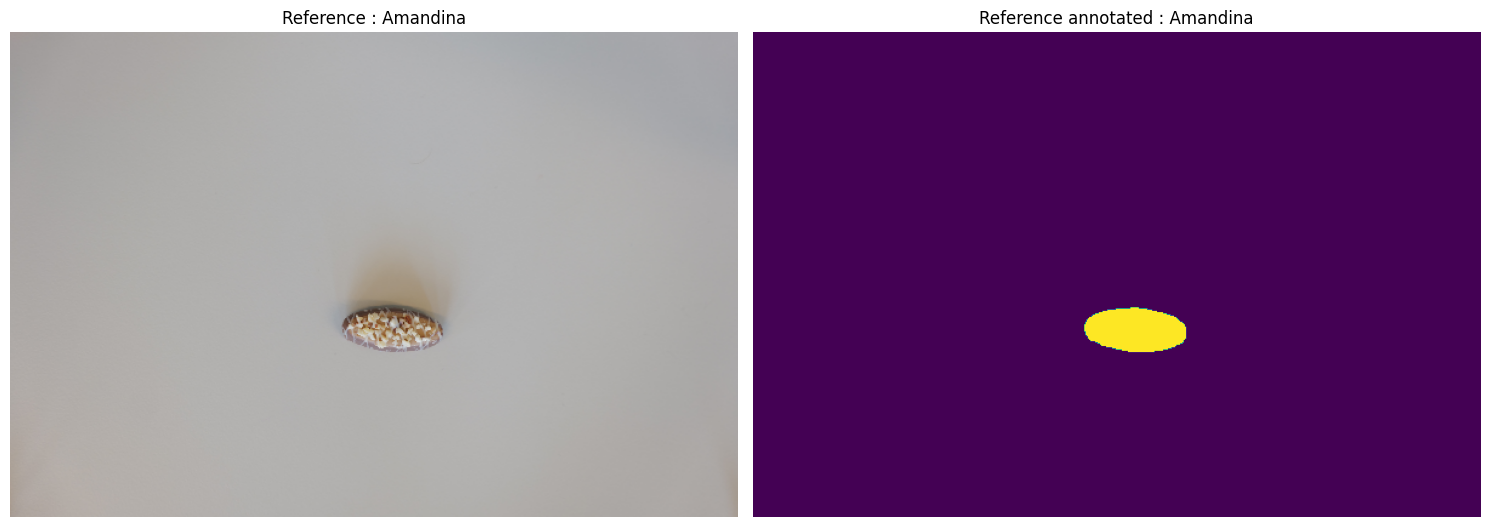

In [9]:
plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 1)
plt.title('Reference : Amandina')
plt.imshow(ref_choco[0])
plt.axis('off')
plt.subplot(1, 2, 2)
plt.title('Reference annotated : Amandina')
plt.imshow(ref_choco_annotated[0])
plt.axis('off')
plt.tight_layout()
plt.show()

An exemple of a reference and its binary image. We compute by hand the contour to have the most perfect form of all the chocolates. Thus, we have a good reference for each chocolate.

# Classification

In this part, the goal is to detect all the chocolates in one image and to classify it with the gived references. To do this, we will use the mask create in the previous part to classify all the chocolate and extract features of the references and the objects to finally classify it.

### Extraction of features

First step is to extract both references and objects features. We extract the contours, the image with only the references/objects in RGB, the number of pixels not equal at zero in the image and the rectangularity. This is made for all the reference and for the image we analyse.

In [ ]:
# Features references
contours_ref, choco, f_rect_ref, sum_choc_annotated = _utils.features_ref(len(ref_choco), ref_choco_annotated, ref_choco)

# Features objects
contours_object, diff_object, f_rect, array_sum = _utils.features_objects(np.max(labels), labels, binned)

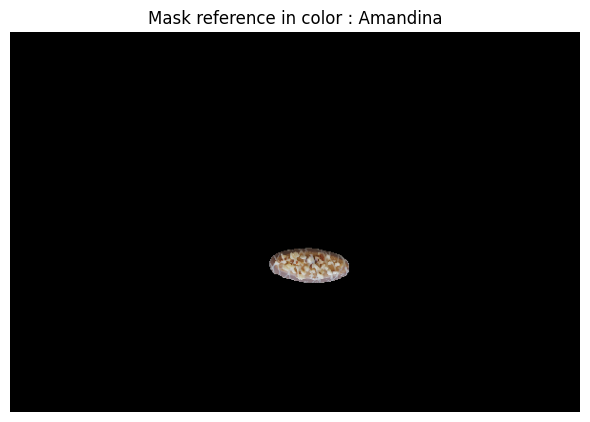

C:\Users\mikae\AppData\Local\Temp\ipykernel_24136\2282456534.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', 13)


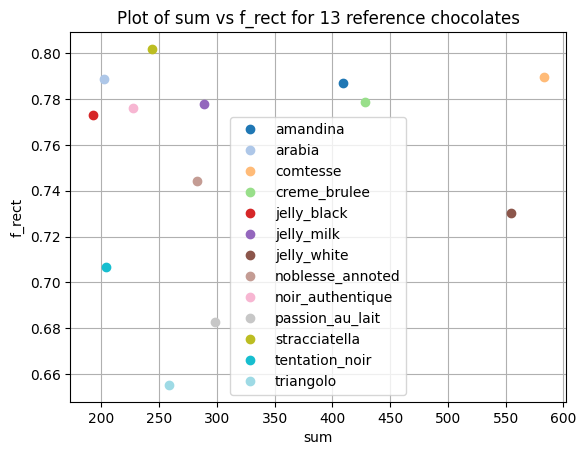

In [12]:
plt.figure(figsize=(6, 6))
plt.title('Mask reference in color : Amandina')
plt.imshow(choco[0])
plt.axis('off')
plt.tight_layout()
plt.show()

colors = plt.cm.get_cmap('tab20', 13)
for i in range(len(ref_choco_annotated)):
    plt.plot(sum_choc_annotated[i], f_rect_ref[i], 'o', color=colors(i), label=chocolates[i])

plt.xlabel('sum')
plt.ylabel('f_rect')
plt.title('Plot of sum vs f_rect for 13 reference chocolates')
plt.legend()
plt.grid(True)
plt.show()

The graph above show a first look at how we proceed for the classification. We calcul the sum of all the pixels of the object and divide by the number of non-zero pixel to have a mean. We also calcul the rectangularity of the object. By comparing theses values with the references by making a treshold on the reference value, we can assign a chocolate type to the object. We will see later in the code that these two features are not sufficient because it lead to false negatives. Thus, we will add a third criterion.

### Fourier descriptors

The third criterion we will add is the fourier descriptor. We will compare the reference with the object and choose the nearest reference as detected chocolate.

C:\Users\mikae\AppData\Local\Temp\ipykernel_24136\1469699927.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend()


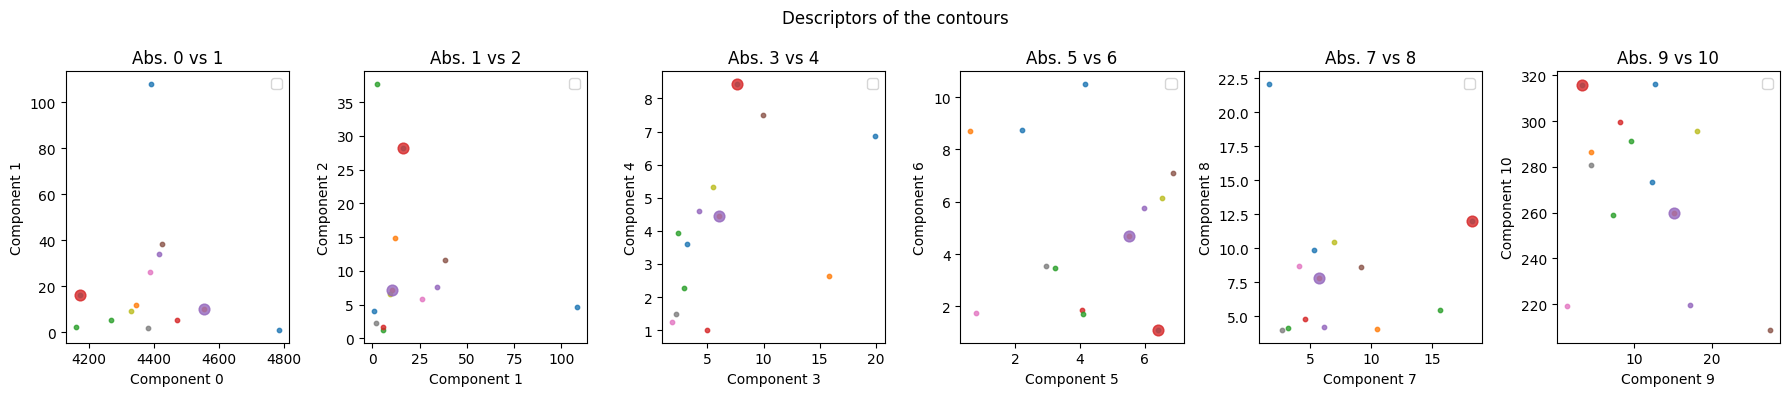

In [26]:
# Fourier descriptors
N = len(contours_ref)
n_samples = 11

contours_inter_ref = _utils.interpolation(contours_ref, n_samples)
descriptors_ref = _utils.compute_descriptor(contours_inter_ref, n_samples)

#contours_inter_object = _utils.interpolation(contours_object, n_samples)
#descriptors_object = _utils.compute_descriptor(contours_inter_object, n_samples)

# Plot features
# Number of paris to display
n_features = descriptors_ref.shape[1]
# Define pairs for 2D plots
pairs = np.array(range(2*np.ceil(n_features / 2).astype(int)))
# Check if odd lenght, shift second feature to have pairs
if n_features % 2 == 1:
    pairs[2:] = pairs[1:-1]
# Convert to 2d array
pairs = pairs.reshape(-1, 2)

# Plot each pairs and labels
n_plots = len(pairs)
_ , axes = plt.subplots(1, n_plots, figsize=(18, 4))

for i, (pa, pb) in enumerate(pairs):
    # Abs
    for n in range(len(ref_choco)):
        axes[i].scatter(np.abs(descriptors_ref[n, pa]), np.abs(descriptors_ref[n, pb]), s=10, alpha=0.8)
    #axes[2, i].scatter(np.abs(descriptors_object[5, pa]), np.abs(descriptors_object[5, pb]), s=60, alpha=0.8)
    axes[i].scatter(np.abs(descriptors_ref[9, pa]), np.abs(descriptors_ref[9, pb]), s=60, alpha=0.8)
    axes[i].scatter(np.abs(descriptors_ref[1, pa]), np.abs(descriptors_ref[1, pb]), s=60, alpha=0.8)
    axes[i].set_xlabel("Component {}".format(pa))
    axes[i].set_ylabel("Component {}".format(pb))
    axes[i].set_title("Abs. {} vs {}".format(pa, pb))
    axes[i].legend()

plt.suptitle("Descriptors of the contours")
plt.tight_layout()

In theses different graphs with different objects (the objects have a bigger circle), we can observe six component more significant than others. Theses components are the 1, 2, 3, 4, 7 and 8. We see on the graph that the object is near of the reference we want. Hence, we will calculate the euclidean distance between the object and all the reference, calculate a mean with all the six components and choose the nearest reference as detected chocolate.

### Classifier

Finally, we build our classifier with the three criterion explained above. First, we detect which reference is the nearest of the object with the fourier descriptors. Second, we use the sum of the pixel and the rectangularity to be certain that the object is a chocolate and not another object, this by analysing the mean color of the object and its form. We design a flexible threshold because a wrong turn countour of the chocolate at the processing stage can quickly alter the sum and rectangularity values. We can see that without the fourier descriptors, the flexibility of our threshold leads to many false negatives (cette phrase est a surement rajouter plus tard).

In [ ]:
# Print the number of chocolates per image
nb_final_choc = np.zeros(len(ref_choco))
for n in range(len(array_sum)):
    dist_descriptor = []
    for i in range(len(ref_choco)):
        component_ref = np.concatenate([descriptors_ref[i][1:4], descriptors_ref[i][7:8]])
        component_object = np.concatenate([descriptors_object[n][1:4], descriptors_object[n][7:8]])
        vector = np.abs(np.abs(component_ref) - np.abs(component_object))
        dist_descriptor.append(np.linalg.norm(vector))
    closest_choco = np.argmin(dist_descriptor)
    print('closest chocolate:', chocolates[closest_choco])
    if ((sum_choc_annotated[closest_choco] - 100) < array_sum[n]) & (f_rect_ref[closest_choco] - 0.1 < f_rect[n]) & (f_rect_ref[closest_choco] + 0.1 > f_rect[n]):
        nb_final_choc[closest_choco] += 1

for i in range(len(ref_choco)):
    print(chocolates[i], ':', nb_final_choc[i], "chocolats dans l'image")